# Notebook 05 — Perbandingan Antar Varian

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/05_comparison.ipynb)

**Anggota yang menggabungkan:** _isi nama di sini_

---

Notebook ini **membaca file CSV history** yang sudah dihasilkan oleh keempat varian (file ada di folder `results/`), lalu menggabungkannya menjadi tabel ringkasan dan grafik komparatif.

**Prasyarat:** keempat anggota sudah commit notebook varian masing-masing dan file `results/*.csv` sudah ada di repo.

## 1. Setup

In [33]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-yakuza'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Working dir: /content/repo
Contents: ['requirements.txt', 'docs', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github', 'results']


In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = 'results'
files = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.csv')])
print('Ditemukan file:', files)


Ditemukan file: ['baseline_history.csv', 'batchnorm_history.csv', 'dropout_0.5_history.csv', 'lr_schedule_history.csv']


## 2. Gabungkan semua history

In [35]:
dfs = []
for f in files:
    df = pd.read_csv(os.path.join(RESULTS_DIR, f))
    dfs.append(df)
all_history = pd.concat(dfs, ignore_index=True)
all_history.head()


,epoch,variant,accuracy,val_accuracy,loss,val_loss
0,1,baseline,0.5897,0.5710,1.1211,1.1676
1,2,baseline,0.6315,0.6138,1.0591,1.0968
2,3,baseline,0.6580,0.6303,0.9948,1.0301
3,4,baseline,0.6681,0.6528,0.9254,0.9608
4,5,baseline,0.6843,0.6834,0.8720,0.8948


## 3. Tabel akurasi akhir per varian

In [36]:
final = all_history.sort_values('epoch').groupby('variant').tail(1)
summary = final[['variant', 'loss', 'val_loss', 'accuracy', 'val_accuracy']]
summary = summary.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
summary


,variant,loss,val_loss,accuracy,val_accuracy
0,dropout_0.5,0.4723,0.5395,0.8614,0.8440
1,batchnorm,0.4113,0.4526,0.8573,0.8417
2,lr_schedule,0.4178,0.4495,0.8507,0.8274
3,baseline,0.5364,0.5815,0.8190,0.8043


## 4. Plot validation accuracy semua varian

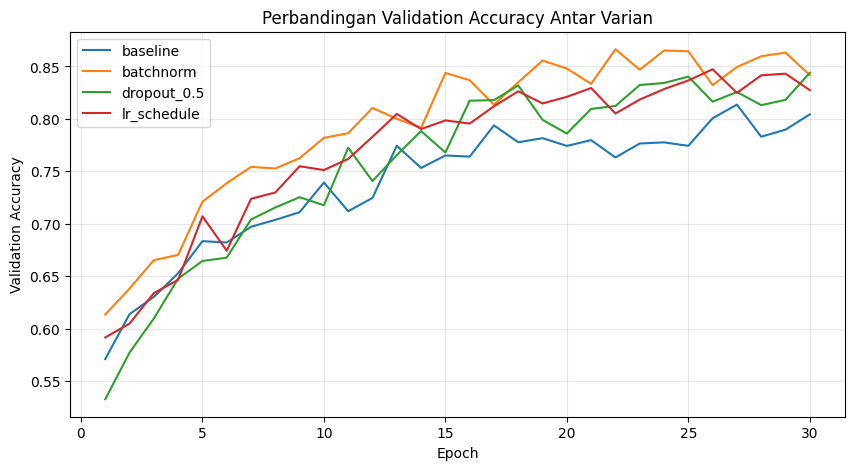

In [37]:
plt.figure(figsize=(10, 5))
for variant, df in all_history.groupby('variant'):
    plt.plot(df['epoch'], df['val_accuracy'], label=variant)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Perbandingan Validation Accuracy Antar Varian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Plot validation loss semua varian

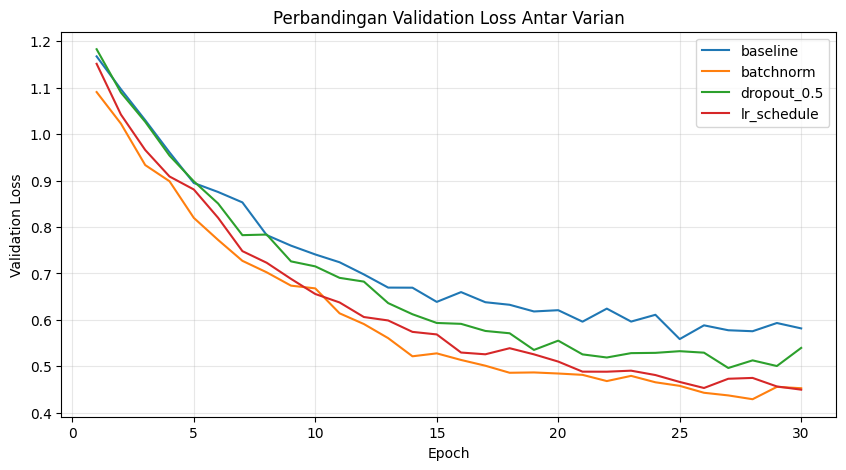

In [38]:
plt.figure(figsize=(10, 5))
for variant, df in all_history.groupby('variant'):
    plt.plot(df['epoch'], df['val_loss'], label=variant)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Perbandingan Validation Loss Antar Varian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 6. Diskusi kelompok
Berdasarkan tabel dan grafik di atas, **isi `docs/REPORT.md`** dengan analisis kelompok. Jangan hanya mendeskripsikan grafik — kaitkan dengan teori di slide kuliah.